In [26]:
import importlib
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import prism
import imagematerials.buildings.constants as bld_const
import imagematerials.buildings.preprocessing.circular_economy_measures as ce_mod
import imagematerials.buildings.preprocessing.main as bld_main
from imagematerials.util import read_circular_economy_config, read_climate_policy_config
import warnings
import copy

# Force reload so the kernel picks up latest code
importlib.reload(bld_const)
importlib.reload(ce_mod)
importlib.reload(bld_main)
from imagematerials.buildings.preprocessing.main import buildings_preprocessing
import matplotlib.pyplot as plt
import logging
from imagematerials.preprocessing import get_preprocessing_data
from imagematerials.read_mym import read_mym_df
import pandas as pd

root - DEBUG - implemented 'base' for Commercial Buildings
root - DEBUG - implemented 'base' for Residential Buildings
root - DEBUG - implemented 'base' for Commercial Buildings
root - DEBUG - implemented 'narrow_activity' for Commercial Buildings with 'relative' target
root - DEBUG - implemented 'base' for Residential Buildings


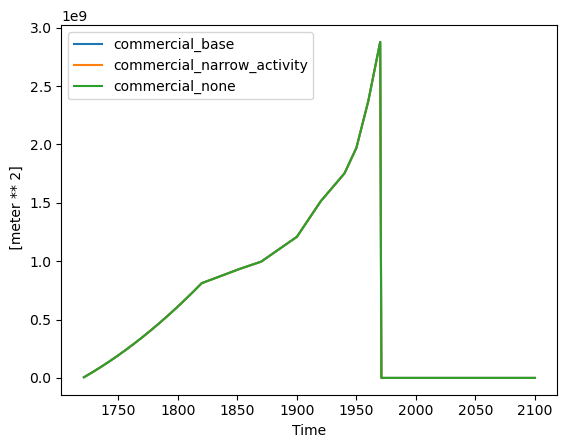

In [27]:
base_dir =  Path("..",  "data", "raw" )
climate_dir = Path("..", "..", "data", "SSP2_baseline")
ce_dir_base = {
    "base": base_dir / "circular_economy_scenarios" /"base"}
ce_dir_narrow_act = {
    "base": base_dir / "circular_economy_scenarios" /"base",
    "narrow_activity": base_dir / "circular_economy_scenarios" /"narrow_activity",
}
ce_dir_none = None

climate_config = read_climate_policy_config(climate_dir)



# add debugging statements
logging.basicConfig(
    level=logging.DEBUG,
    format='%(name)s - %(levelname)s - %(message)s',
    force=True  # Override any existing config
)

with warnings.catch_warnings():
    warnings.filterwarnings("ignore")
    prep_none = get_preprocessing_data("buildings", Path("..", "data", "raw"), 
                                        climate_dir, 
                                        ce_dir_none) 
    prep_base = buildings_preprocessing(base_dir, climate_config, read_circular_economy_config(ce_dir_base))
    prep_narrow_act = buildings_preprocessing(base_dir, climate_config, read_circular_economy_config(ce_dir_narrow_act)) 

prep_base.get("stocks").sel(Type = ['Office',
       'Retail+', 'Hotels+', 'Govt+']).sum(["Region", "Type"]).plot(label = 'commercial_base')
prep_narrow_act.get("stocks").sel(Type = ['Office',
       'Retail+', 'Hotels+', 'Govt+']).sum(["Region", "Type"]).plot(label = 'commercial_narrow_activity')
prep_none.prep_data.get("stocks").sel(Type = ['Office',
       'Retail+', 'Hotels+', 'Govt+']).sum(["Region", "Type"]).plot(label = 'commercial_none')
plt.legend()



In [28]:
# Test if the two CE modes modes give different results for commercial floorspace

comm_types = ["Office", "Retail+", "Hotels+", "Govt+"]
results = {}

# Parse the raw directory paths into an actual config dict
ce_cfg = read_circular_economy_config(ce_dir_narrow_act)

with warnings.catch_warnings():
    warnings.filterwarnings("ignore")
    for mode in ("relative", "convergence"):
        # Override commercial_ce_mode in the config for each run
        ce_cfg_run = copy.deepcopy(ce_cfg)
        ce_cfg_run["narrow_activity"]["buildings"]["commercial_ce_mode"] = mode
        print(f"--- Running mode: {mode} ---")
        prep = buildings_preprocessing(base_dir, climate_config, ce_cfg_run)

        stocks = prep["stocks"]
        print(stocks)
        stocks_comm = stocks.sel(Type=comm_types).sum("Type")

        n_nan = int(np.isnan(stocks_comm.values).sum())
        n_inf = int(np.isinf(stocks_comm.values).sum())
        total = float(np.nansum(stocks_comm.values[np.isfinite(stocks_comm.values)]))
        print(f"  NaN: {n_nan}, inf: {n_inf}, finite-sum: {total:.2e}")

        results[mode] = stocks_comm

print(f"\nRelative vs convergence differ? {not results['relative'].equals(results['convergence'])}")





--- Running mode: relative ---


root - DEBUG - implemented 'base' for Commercial Buildings
root - DEBUG - implemented 'narrow_activity' for Commercial Buildings with 'relative' target
root - DEBUG - implemented 'base' for Residential Buildings


<xarray.DataArray (Time: 380, Region: 26, Type: 12)> Size: 948kB
<Quantity([[[1.94046845e+04 2.33900918e+03 3.18723684e+05 ... 5.42262826e+02
   1.48782863e+03 3.09874480e+04]
  [5.74165730e+04 9.96550594e+03 3.41048739e+06 ... 5.02677235e+03
   1.37921603e+04 2.87253411e+05]
  [4.94253083e+04 4.99773652e+03 8.11815127e+05 ... 1.28569549e+03
   3.52761515e+03 7.34706867e+04]
  ...
  [6.17110671e+03 1.60685185e+03 1.91745101e+05 ... 4.29782460e+02
   1.17921166e+03 2.45597909e+04]
  [2.27727454e+05 3.87398324e+03 2.30547359e+06 ... 4.11580505e+03
   1.12927021e+04 2.35196456e+05]
  [4.31836499e+04 8.58216442e+02 7.09295326e+05 ... 1.14686957e+03
   3.14671281e+03 6.55375207e+04]]

 [[3.88485641e+04 4.92032016e+03 6.38091154e+05 ... 1.08884957e+03
   2.98752097e+03 6.22219849e+04]
  [1.14958863e+05 2.09633550e+04 6.82844225e+06 ... 1.00936274e+04
   2.76942970e+04 5.76797335e+05]
  [9.90152136e+04 1.05131968e+04 1.62633377e+06 ... 2.58164291e+03
   7.08335894e+03 1.47527217e+05]
...
  [2

root - DEBUG - implemented 'base' for Commercial Buildings
root - DEBUG - implemented 'narrow_activity' for Commercial Buildings with 'convergence' target
root - DEBUG - implemented 'base' for Residential Buildings


<xarray.DataArray (Time: 380, Region: 26, Type: 12)> Size: 948kB
<Quantity([[[1.94046845e+04 2.33900918e+03 3.18723684e+05 ... 5.42262826e+02
   1.48782863e+03 3.09874480e+04]
  [5.74165730e+04 9.96550594e+03 3.41048739e+06 ... 5.02677235e+03
   1.37921603e+04 2.87253411e+05]
  [4.94253083e+04 4.99773652e+03 8.11815127e+05 ... 1.28569549e+03
   3.52761515e+03 7.34706867e+04]
  ...
  [6.17110671e+03 1.60685185e+03 1.91745101e+05 ... 4.29782460e+02
   1.17921166e+03 2.45597909e+04]
  [2.27727454e+05 3.87398324e+03 2.30547359e+06 ... 4.11580505e+03
   1.12927021e+04 2.35196456e+05]
  [4.31836499e+04 8.58216442e+02 7.09295326e+05 ... 1.14686957e+03
   3.14671281e+03 6.55375207e+04]]

 [[3.88485641e+04 4.92032016e+03 6.38091154e+05 ... 1.08884957e+03
   2.98752097e+03 6.22219849e+04]
  [1.14958863e+05 2.09633550e+04 6.82844225e+06 ... 1.00936274e+04
   2.76942970e+04 5.76797335e+05]
  [9.90152136e+04 1.05131968e+04 1.62633377e+06 ... 2.58164291e+03
   7.08335894e+03 1.47527217e+05]
...
  [2

Text(0.5, 1.0, 'Commercial floorspace stock by type (all regions)')

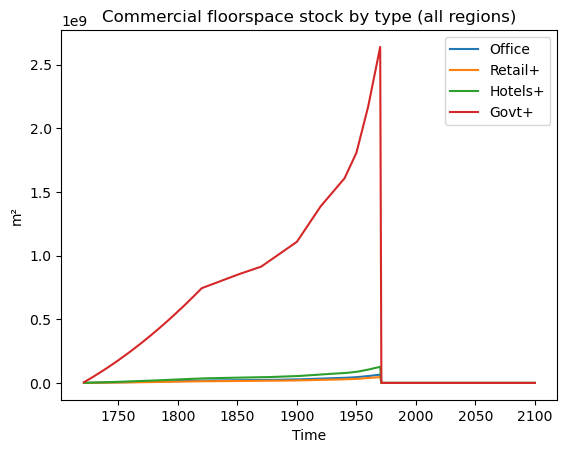

In [29]:
comm_types = ['Office', 'Retail+', 'Hotels+', 'Govt+']
stocks = prep.get("stocks").sel(Type=comm_types).sum("Region")
for t in comm_types:
    stocks.sel(Type=t).plot(label=t)
plt.legend()
plt.ylabel("m²")
plt.title("Commercial floorspace stock by type (all regions)")

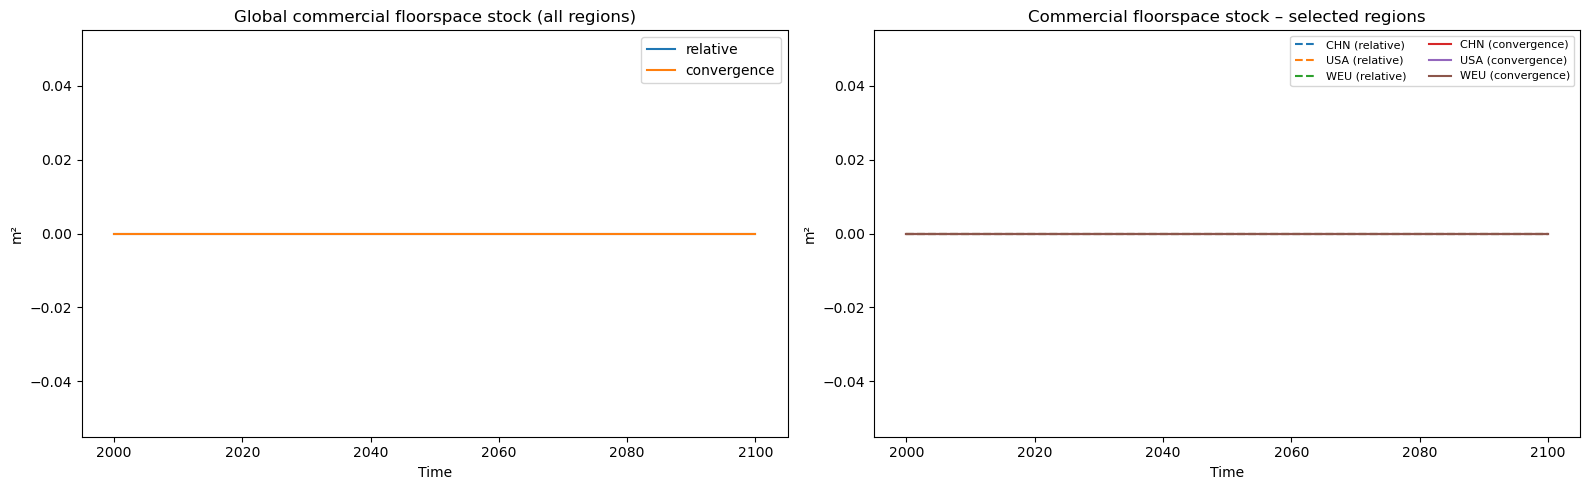

In [30]:

# --- Plot 1: Global total commercial floorspace (all regions summed) ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for mode, stocks in results.items():
    total = stocks.sum("Region").loc[2000:]
    if prism.U_(total) is not None:
        total = total.pint.to("m**2")
    total.plot(ax=axes[0], label=mode)
axes[0].set_title("Global commercial floorspace stock (all regions)")
axes[0].set_ylabel("m²")
axes[0].legend()

# --- Plot 2: Per-region comparison for a few selected regions ---
sample_regions = ["CHN", "USA", "IND", "WEU"]
available = [r for r in sample_regions if r in results["relative"].coords["Region"].values]

for mode, stocks in results.items():
    for reg in available:
        series = stocks.sel(Region=reg).loc[2000:]
        if prism.U_(series) is not None:
            series = series.pint.to("m**2")
        linestyle = "-" if mode == "convergence" else "--"
        series.plot(ax=axes[1], label=f"{reg} ({mode})", linestyle=linestyle)
axes[1].set_title("Commercial floorspace stock – selected regions")
axes[1].set_ylabel("m²")
axes[1].legend(fontsize=8, ncol=2)

plt.tight_layout()
plt.show()

c:\Users\5982758\AppData\Local\anaconda3\envs\materials\Lib\site-packages\numpy\lib\_function_base_impl.py:2642: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  args = tuple(asanyarray(arg) for arg in args)
c:\Users\5982758\AppData\Local\anaconda3\envs\materials\Lib\site-packages\numpy\lib\_function_base_impl.py:2642: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  args = tuple(asanyarray(arg) for arg in args)
c:\Users\5982758\AppData\Local\anaconda3\envs\materials\Lib\site-packages\numpy\lib\_function_base_impl.py:2642: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  args = tuple(asanyarray(arg) for arg in args)
c:\Users\5982758\AppData\Local\anaconda3\envs\materials\Lib\site-packages\numpy\lib\_function_base_impl.py:2642: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  args = tuple(asanyarray(arg) for arg in args)
c:\Users

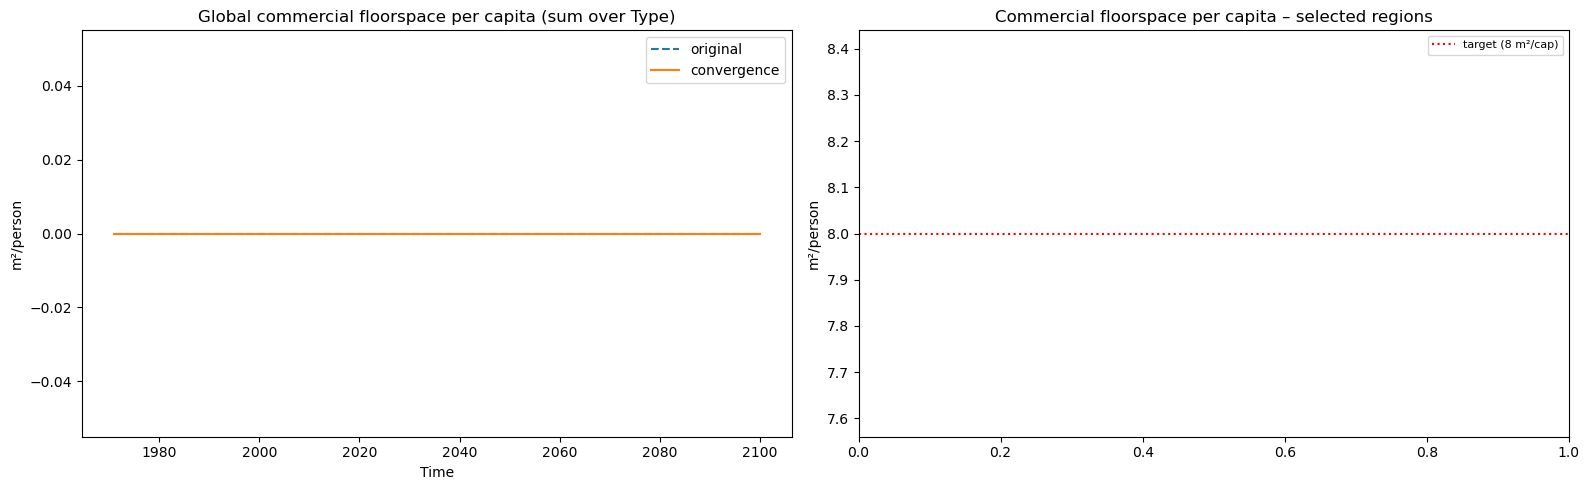


Computed pct_change (convergence target vs start):


In [31]:
import xarray as xr
from imagematerials.util import apply_change_per_region
from imagematerials.buildings.preprocessing.floorspace import (
    get_image_floorspace, extrapolate_floorspace,
)

# --- Get the raw commercial floorspace (before any CE adjustments) ---
image_dir = Path(climate_config["config_file_path"])
with warnings.catch_warnings():
    warnings.filterwarnings("ignore")
    floorspace_image, minimum_comm = get_image_floorspace(image_dir, base_dir)
    floorspace_all = extrapolate_floorspace(floorspace_image, minimum_comm)

comm_types_test = ["Office", "Retail+", "Hotels+", "Govt+"]
floorspace_commercial = floorspace_all.sel(
    Type=[t for t in floorspace_all.coords["Type"].values if t not in ("Urban", "Rural")]
)

# --- Apply the convergence logic directly ---
convergence_year_start = 2025
convergence_year_end = 2100
convergence_target_val = 8.0  # m²/person
implementation_rate = "linear"

total_at_start = floorspace_commercial.sel(Time=convergence_year_start).sum(dim="Type")
conv_target = prism.Q_(convergence_target_val, prism.U_(total_at_start)) \
    if prism.U_(total_at_start) is not None else convergence_target_val

pct_change = ((conv_target - total_at_start) / total_at_start) * 100
pct_change = xr.where(np.isfinite(pct_change), pct_change, 0)

floorspace_converged = apply_change_per_region(
    floorspace_commercial, convergence_year_start, convergence_year_end,
    pct_change, implementation_rate,
)

# --- Compare: original vs converged (sum over Type, per-capita) ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sample_regions = ["CHN", "USA", "INDIA", "WEU"]
available = [r for r in sample_regions
             if r in floorspace_commercial.coords["Region"].values]

# Left: global total
orig_global = floorspace_commercial.sum(["Region", "Type"]).loc[1971:]
conv_global = floorspace_converged.sum(["Region", "Type"]).loc[1971:]
orig_global.plot(ax=axes[0], label="original", linestyle="--")
conv_global.plot(ax=axes[0], label="convergence")
axes[0].set_title("Global commercial floorspace per capita (sum over Type)")
axes[0].set_ylabel("m²/person")
axes[0].legend()

# Right: selected regions
for reg in available:
    orig_r = floorspace_commercial.sel(Region=reg).sum("Type").loc[1971:]
    conv_r = floorspace_converged.sel(Region=reg).sum("Type").loc[1971:]
    orig_r.plot(ax=axes[1], label=f"{reg} (original)", linestyle="--")
    conv_r.plot(ax=axes[1], label=f"{reg} (convergence)")
axes[1].axhline(y=convergence_target_val, color="red", linestyle=":", label="target (8 m²/cap)")
axes[1].set_title("Commercial floorspace per capita – selected regions")
axes[1].set_ylabel("m²/person")
axes[1].legend(fontsize=8, ncol=2)

plt.tight_layout()
plt.show()

# Print the pct_change for a few regions
print("\nComputed pct_change (convergence target vs start):")
for reg in available:
    val = float(pct_change.sel(Region=reg).values)
    start_val = float(total_at_start.sel(Region=reg).values)
    print(f"  {reg}: start={start_val:.2f} m²/cap, pct_change={val:.1f}%")

# Exploring commercial floorspace intermediate data (CE = None)

Step through the individual functions behind `get_image_floorspace` to inspect
`service_value_added`, `commercial_m2_cap_sum`, and `commercial_m2_cap`.

In [32]:
from imagematerials.buildings.preprocessing.floorspace import (
    get_gompertz,
    get_service_value_added,
    compute_commercial_floor_m2_cap_sum,
    compute_commercial_floor_m2_cap,
)

image_directory = Path(climate_config["config_file_path"])

# 1. Gompertz parameters
gompertz = get_gompertz(base_dir)
print("Gompertz parameters:")
display(gompertz)

# 2. Service value added (inflation-adjusted)
service_value_added = get_service_value_added(image_directory)
print(f"\nService value added shape: {service_value_added.shape}")
display(service_value_added.head(10))

# 3. Total commercial floorspace per capita (summed across types)
commercial_m2_cap_sum = compute_commercial_floor_m2_cap_sum(gompertz, service_value_added)
print(f"\ncommercial_m2_cap_sum shape: {commercial_m2_cap_sum.shape}")
display(commercial_m2_cap_sum.head(10))

# 4. Commercial floorspace per capita by type
commercial_m2_cap, minimum_comm = compute_commercial_floor_m2_cap(
    gompertz, commercial_m2_cap_sum, service_value_added
)
print(f"\ncommercial_m2_cap shape: {commercial_m2_cap.shape}")
display(commercial_m2_cap.head(10))
print(f"\nMinimum commercial values:\n{minimum_comm}")

Gompertz parameters:


,All,Office,Retail+,Govt+,Hotels+
a,25.600531,4.2530,8.0100,9.9800,3.0830
b,3.289102,5.5400,6.5240,2.6520,4.5270
c,0.072218,0.0695,0.0633,0.0517,0.0479



Service value added shape: (131, 28)


,1,2,3,4,5,6,7,8,9,10,...,19,20,21,22,23,24,25,26,27,28
time,,,,,,,,,,,,,,,,,,,,,
1970,13989.652107,17894.747619,6466.942968,3525.429997,4119.081687,4687.869984,2555.515453,1355.897154,670.844982,7074.697247,...,1030.778051,168.839378,1075.761237,703.897491,8670.391844,10789.459976,831.850167,1225.764366,0.0,3512.572192
1971,13989.652107,17894.747619,6466.942968,3525.429997,4119.081687,4687.869984,2555.515453,1355.897154,670.844982,7074.697247,...,1030.778051,168.839378,1075.761237,703.897491,8670.391844,10789.459976,831.850167,1225.764366,0.0,3512.572192
1972,14613.845742,18580.695987,6866.246761,3669.309457,4563.892171,4668.596942,2740.879036,1398.963968,645.279690,6850.674531,...,1076.587864,175.678115,1077.273116,750.503742,9386.643636,10777.089153,737.089511,1223.970857,0.0,3655.527380
1973,14800.923699,19208.827713,7145.700904,3768.200263,4878.494708,4757.005222,2660.368058,1421.055789,626.040190,6770.494004,...,1184.565226,183.835554,1105.142875,781.065813,9867.857237,11108.959660,719.397792,1255.208739,0.0,3758.933948
1974,14851.100196,19133.892177,7145.391571,3743.760496,5094.436263,4713.191785,2324.320939,1442.991080,637.176664,6717.983225,...,1299.358839,184.086747,1080.016860,810.259863,9917.699555,11687.210556,737.979867,1247.297773,0.0,3745.027642
1975,15350.144529,19086.982929,7334.844806,3784.693038,5335.403952,4962.195913,2619.590803,1459.216761,679.200816,6669.067663,...,1352.388899,184.335704,1114.910955,872.527293,10473.899627,11883.529983,718.145306,1211.034415,0.0,3826.706382
1976,16242.202890,19856.115705,7494.630674,3876.639388,5740.983844,4891.776137,2736.179415,1500.305833,708.946944,6706.534189,...,1499.203913,185.655772,1176.128145,908.738847,10820.353493,12132.814870,763.947416,1161.320178,0.0,3972.453018
1977,16598.171532,20508.646203,7374.388457,4062.891216,5871.247695,5122.814122,2933.360998,1586.130129,720.040558,6606.219706,...,1664.699392,209.628559,1245.420658,953.327355,11385.108042,12191.846481,765.748130,1127.002510,0.0,4110.796788
1978,17023.535052,21434.122434,7781.466563,4227.727034,6137.181887,5238.484675,3238.810268,1501.385392,710.076691,6461.324045,...,1813.175361,231.093888,1335.435231,1011.683279,11906.425572,12291.593233,811.498933,1085.971328,0.0,4250.907109


C:\Users\5982758\repos\image-materials\imagematerials\buildings\preprocessing\floorspace.py:263: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

Try using '.loc[row_indexer, col_indexer] = value' instead, to perform the assignment in a single step.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html#chained-assignment
  commercial_m2_cap[region][year] = alpha * math.exp(-beta * exp_factor)
C:\Users\5982758\repos\image-materials\imagematerials\buildings\preprocessing\floorspace.py:264: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame o

...

,1,2,3,4,5,6,7,8,9,10,...,17,18,19,20,21,22,23,24,25,26
1970,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1971,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1972,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1973,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1974,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1975,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1976,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1977,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1978,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1979,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


C:\Users\5982758\repos\image-materials\imagematerials\buildings\preprocessing\floorspace.py:321: PerformanceWarning: indexing past lexsort depth may impact performance.
  commercial_m2_cap_all.loc[(type_, region, year), "m2_per_cap"] = (



commercial_m2_cap shape: (3406, 4)


Type        Govt+ Hotels+ Office Retail+
Region Time                             
1      1970     0       0      0       0
       1971   NaN     NaN    NaN     NaN
       1972   NaN     NaN    NaN     NaN
       1973   NaN     NaN    NaN     NaN
       1974   NaN     NaN    NaN     NaN
       1975   NaN     NaN    NaN     NaN
       1976   NaN     NaN    NaN     NaN
       1977   NaN     NaN    NaN     NaN
       1978   NaN     NaN    NaN     NaN
       1979   NaN     NaN    NaN     NaN


Minimum commercial values:
<xarray.DataArray (Type: 4)> Size: 32B
array([0.01781442, 0.0126013 , 0.03457471, 0.72009772])
Coordinates:
  * Type     (Type) <U7 112B 'Office' 'Retail+' 'Hotels+' 'Govt+'


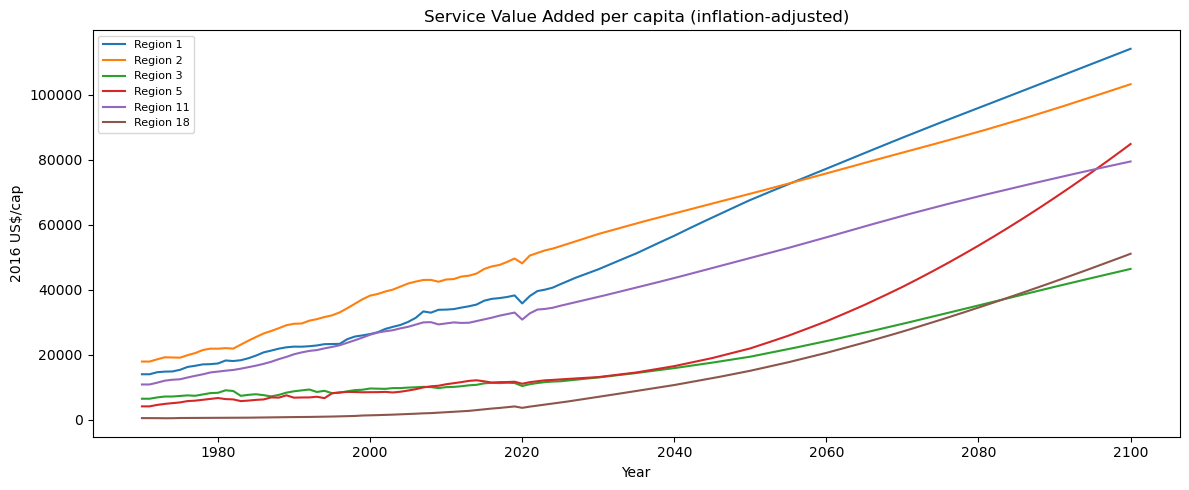

In [33]:
# --- Plot service_value_added for a selection of regions ---
fig, ax = plt.subplots(figsize=(12, 5))
sample_regions = [1, 2, 3, 5, 11, 18]  # a handful of IMAGE regions
for reg in sample_regions:
    if reg in service_value_added.columns:
        service_value_added[reg].plot(ax=ax, label=f"Region {reg}")
ax.set_title("Service Value Added per capita (inflation-adjusted)")
ax.set_ylabel("2016 US$/cap")
ax.set_xlabel("Year")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

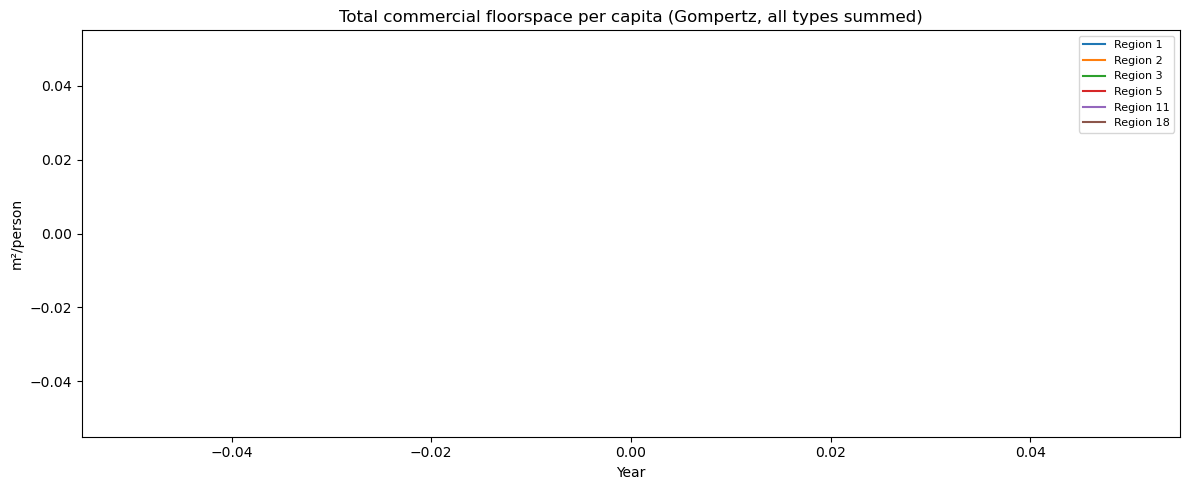

In [34]:
# --- Plot commercial_m2_cap_sum (total commercial m²/cap) for selected regions ---
fig, ax = plt.subplots(figsize=(12, 5))
for reg in sample_regions:
    if reg in commercial_m2_cap_sum.columns:
        commercial_m2_cap_sum[reg].astype(float).plot(ax=ax, label=f"Region {reg}")
ax.set_title("Total commercial floorspace per capita (Gompertz, all types summed)")
ax.set_ylabel("m²/person")
ax.set_xlabel("Year")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

KeyError: 3

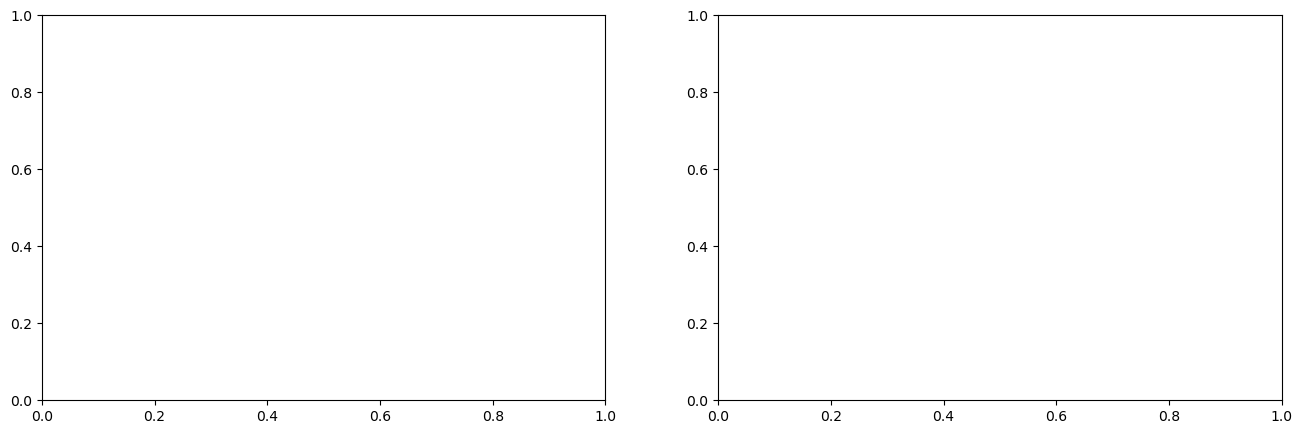

In [35]:
# --- Plot commercial_m2_cap by type for a single region ---
idx = pd.IndexSlice
plot_region = 3  # Change to inspect a different region
comm_types = ["Office", "Retail+", "Hotels+", "Govt+"]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: stacked area for one region
region_data = commercial_m2_cap.loc[idx[:, plot_region], comm_types].droplevel("Region").astype(float)
region_data.plot.area(ax=axes[0], alpha=0.7)
axes[0].set_title(f"Commercial m²/cap by type – Region {plot_region}")
axes[0].set_ylabel("m²/person")
axes[0].set_xlabel("Year")

# Right: all regions summed, by type
all_regions_sum = commercial_m2_cap[comm_types].astype(float).groupby(level="Time").sum()
all_regions_sum.plot(ax=axes[1])
axes[1].set_title("Commercial m²/cap by type (summed over all regions)")
axes[1].set_ylabel("m²/person (sum across regions)")
axes[1].set_xlabel("Year")

plt.tight_layout()
plt.show()